In [1]:
# ============================================================
# NOTEBOOK: 4_python_processing.ipynb
# PURPOSE:
# Advanced Python Data Processing and Analytics
# ============================================================

# ============================================================
# STEP 1 — IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os

# ============================================================
# STEP 2 — EXTRACT DATASET
# ============================================================

zip_path = "/content/northstar_dataset.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/data")

print("DATASET EXTRACTED SUCCESSFULLY!")

# ============================================================
# STEP 3 — LOAD DATASETS
# ============================================================

customers = pd.read_csv('/content/data/northstar_dataset/customers.csv')
orders = pd.read_csv('/content/data/northstar_dataset/orders.csv')
deliveries = pd.read_csv('/content/data/northstar_dataset/deliveries.csv')
drivers = pd.read_csv('/content/data/northstar_dataset/drivers.csv')
vehicles = pd.read_csv('/content/data/northstar_dataset/vehicles.csv')
complaints = pd.read_csv('/content/data/northstar_dataset/complaints.csv')
incidents = pd.read_csv('/content/data/northstar_dataset/incidents.csv')
hubs = pd.read_csv('/content/data/northstar_dataset/hubs.csv')
app_events = pd.read_csv('/content/data/northstar_dataset/app_events.csv')

print("ALL DATASETS LOADED!")

DATASET EXTRACTED SUCCESSFULLY!
ALL DATASETS LOADED!


In [2]:
# ============================================================
# STEP 4 — DATA CLEANING
# ============================================================

# Convert dates

customers['signup_date'] = pd.to_datetime(customers['signup_date'])
orders['order_created_at'] = pd.to_datetime(orders['order_created_at'])
deliveries['dispatch_time'] = pd.to_datetime(deliveries['dispatch_time'])
deliveries['delivery_completed_at'] = pd.to_datetime(
    deliveries['delivery_completed_at']
)

complaints['created_at'] = pd.to_datetime(complaints['created_at'])

incidents['reported_at'] = pd.to_datetime(incidents['reported_at'])

app_events['event_timestamp'] = pd.to_datetime(
    app_events['event_timestamp']
)

print("DATE CONVERSION COMPLETE!")

# Fill missing values

customers['loyalty_score'].fillna(
    customers['loyalty_score'].mean(),
    inplace=True
)

drivers['training_score'].fillna(
    drivers['training_score'].mean(),
    inplace=True
)

vehicles['battery_health_pct'].fillna(
    vehicles['battery_health_pct'].mean(),
    inplace=True
)

complaints['compensation_amount'].fillna(
    complaints['compensation_amount'].median(),
    inplace=True
)

print("MISSING VALUES HANDLED!")

DATE CONVERSION COMPLETE!
MISSING VALUES HANDLED!


/tmp/ipykernel_3532/2371277901.py:26: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  customers['loyalty_score'].fillna(
/tmp/ipykernel_3532/2371277901.py:31: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.me

In [3]:
# ============================================================
# STEP 5 — CREATE MASTER DATASET
# ============================================================

master_df = deliveries.merge(
    orders,
    on='order_id',
    how='left'
)

master_df = master_df.merge(
    customers,
    on='customer_id',
    how='left'
)

master_df = master_df.merge(
    drivers,
    on='driver_id',
    how='left'
)

master_df = master_df.merge(
    vehicles,
    on='vehicle_id',
    how='left'
)

master_df = master_df.merge(
    hubs,
    on='hub_id',
    how='left'
)

print("MASTER DATASET CREATED!")

print(master_df.shape)

MASTER DATASET CREATED!
(950, 49)


delivery_status
OnTime     616
Delayed    202
Failed     132
Name: count, dtype: int64


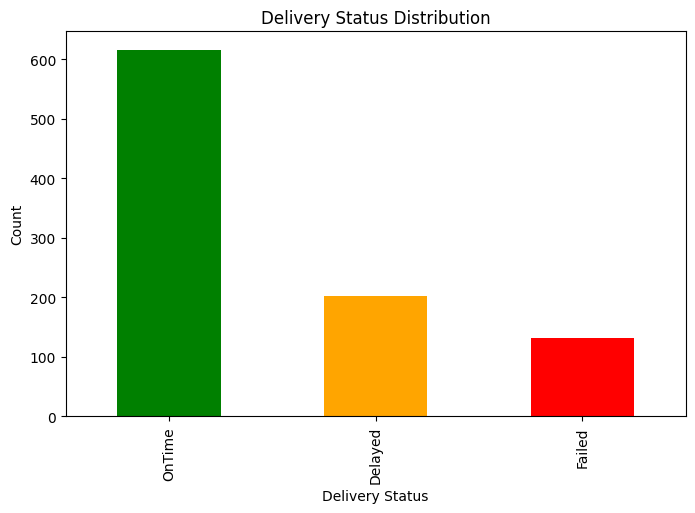

In [4]:
# ============================================================
# STEP 6 — DELIVERY FAILURE ANALYSIS
# ============================================================

failure_counts = master_df['delivery_status'].value_counts()

print(failure_counts)

# Visualisation

plt.figure(figsize=(8,5))

failure_counts.plot(
    kind='bar',
    color=['green', 'orange', 'red']
)

plt.title('Delivery Status Distribution')
plt.xlabel('Delivery Status')
plt.ylabel('Count')

plt.show()

INTERPRETATION:

Operational delivery outcomes reveal that delayed and failed deliveries
represent a significant proportion of total operations.

This indicates ongoing inefficiencies in dispatch coordination,
route execution, or operational management.

         hub_name  total_deliveries  avg_fuel_cost  avg_customer_rating
0     Airport Hub               104      13.319231             3.882136
1    Central Core               115      13.686000             3.669558
2       East Dock               119      12.744202             3.895862
3   Midtown Relay               128      11.708203             3.884560
4  North Exchange               136      12.755809             3.840593
5   Riverside Hub               115      12.922087             3.881858
6      South Link               106      12.565000             3.950952
7       West Gate               127      13.167008             3.915476


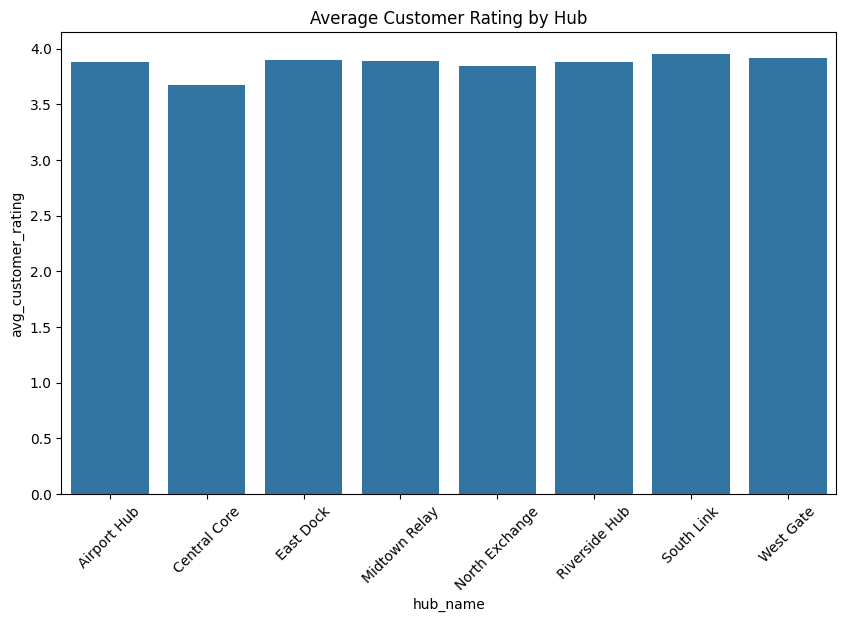

In [5]:
# ============================================================
# STEP 7 — HUB PERFORMANCE ANALYSIS
# ============================================================

hub_analysis = master_df.groupby(
    'hub_name'
).agg({
    'delivery_id':'count',
    'fuel_or_charge_cost':'mean',
    'customer_rating_post_delivery':'mean'
}).reset_index()

hub_analysis.columns = [
    'hub_name',
    'total_deliveries',
    'avg_fuel_cost',
    'avg_customer_rating'
]

print(hub_analysis)

# Visualisation

plt.figure(figsize=(10,6))

sns.barplot(
    data=hub_analysis,
    x='hub_name',
    y='avg_customer_rating'
)

plt.xticks(rotation=45)

plt.title('Average Customer Rating by Hub')

plt.show()

INTERPRETATION:

Hub-level performance analysis reveals operational variation
between locations.

Lower customer ratings may indicate dispatch inefficiency,
resource constraints, or delivery quality problems.

In [6]:
# ============================================================
# STEP 8 — DRIVER RISK ANALYSIS
# ============================================================

driver_risk = master_df.groupby(
    'driver_id'
).agg({
    'manual_route_override_count':'mean',
    'customer_rating_post_delivery':'mean',
    'delivery_id':'count'
}).reset_index()

driver_risk.columns = [
    'driver_id',
    'avg_route_overrides',
    'avg_customer_rating',
    'total_deliveries'
]

print(driver_risk.head())

# High-risk drivers

high_risk_drivers = driver_risk[
    driver_risk['avg_route_overrides'] > 1.5
]

print("\nHIGH RISK DRIVERS")
print(high_risk_drivers)

  driver_id  avg_route_overrides  avg_customer_rating  total_deliveries
0      D001             0.666667             4.096667                 6
1      D002             1.000000             3.210000                 7
2      D003             1.750000             4.445000                 4
3      D004             0.777778             3.510000                 9
4      D005             1.200000             3.530000                 5

HIGH RISK DRIVERS
    driver_id  avg_route_overrides  avg_customer_rating  total_deliveries
2        D003             1.750000             4.445000                 4
20       D021             2.500000             3.105000                 2
26       D027             1.833333             3.645000                 6
27       D028             1.857143             3.537143                 7
32       D033             1.571429             3.947143                 7
41       D042             1.666667             4.013333                 3
50       D051             2.000

INTERPRETATION:

Drivers with unusually high manual route override behaviour
may indicate operational instability, route-planning issues,
or inconsistent dispatch management.

  vehicle_type  battery_health_pct  fuel_or_charge_cost  delivery_id
0     CargoVan           72.079372            12.842422          223
1       Diesel           71.209722            12.853056          144
2           EV           81.953428            12.925988          339
3       Hybrid           77.892301            12.715656          244


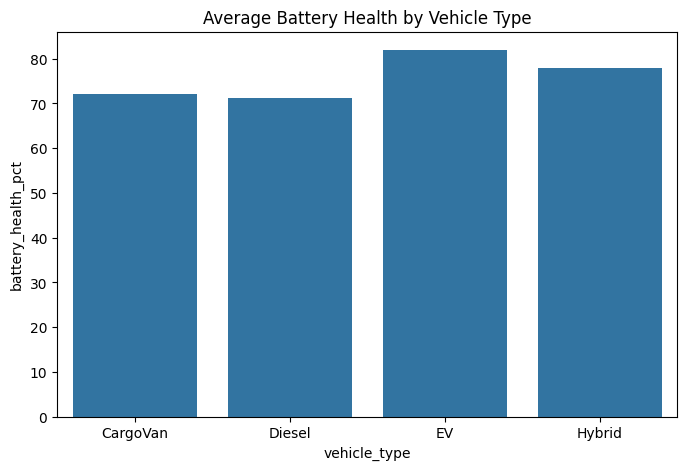

In [7]:
# ============================================================
# STEP 9 — VEHICLE HEALTH ANALYSIS
# ============================================================

vehicle_analysis = master_df.groupby(
    'vehicle_type'
).agg({
    'battery_health_pct':'mean',
    'fuel_or_charge_cost':'mean',
    'delivery_id':'count'
}).reset_index()

print(vehicle_analysis)

# Visualisation

plt.figure(figsize=(8,5))

sns.barplot(
    data=vehicle_analysis,
    x='vehicle_type',
    y='battery_health_pct'
)

plt.title('Average Battery Health by Vehicle Type')

plt.show()

INTERPRETATION:

Fleet analysis helps identify operational risks associated
with battery degradation and vehicle condition.

Poor fleet condition may contribute to delays,
higher operational costs, and incidents.

      complaint_type  count
0           AppIssue     53
1            Billing     16
2             Damage     15
3              Delay    101
4    DriverBehaviour     51
5       MissedPickup     64
6  SupportExperience     20


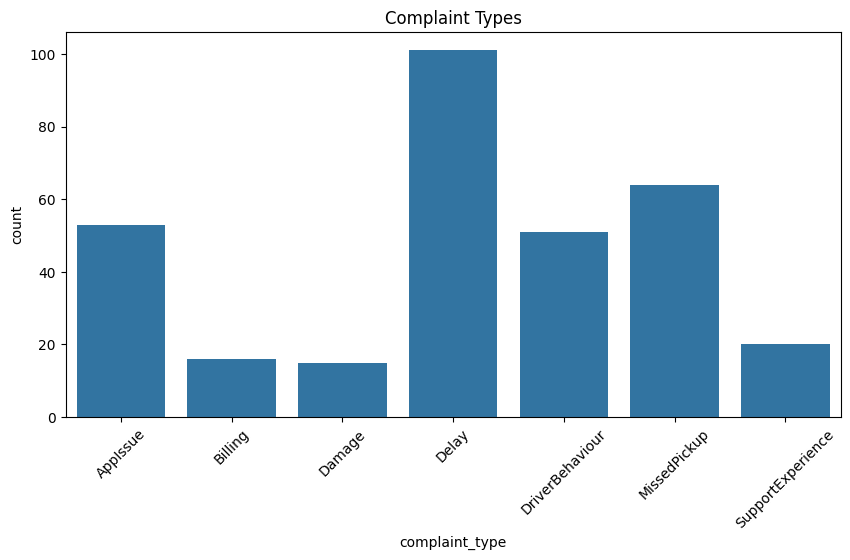

In [8]:
# ============================================================
# STEP 10 — CUSTOMER COMPLAINT ANALYSIS
# ============================================================

complaint_analysis = complaints.groupby(
    'complaint_type'
).size().reset_index(name='count')

print(complaint_analysis)

# Visualisation

plt.figure(figsize=(10,5))

sns.barplot(
    data=complaint_analysis,
    x='complaint_type',
    y='count'
)

plt.xticks(rotation=45)

plt.title('Complaint Types')

plt.show()

INTERPRETATION:

Complaint analysis identifies the most common service issues
experienced by customers.

Frequent complaint categories may reveal weaknesses
in operational execution and customer support processes.

                    event_type  api_latency_ms  success_flag
0               cancel_attempt      417.142857      1.000000
1               chat_escalated      478.131579      0.500000
2                  chat_opened      478.329545      1.000000
3  delivery_instruction_update      496.293333      1.000000
4                  eta_refresh      452.152381      1.000000
5                payment_retry      472.681159      0.724638
6                 search_route      456.505051      1.000000
7                  track_order      460.710145      1.000000


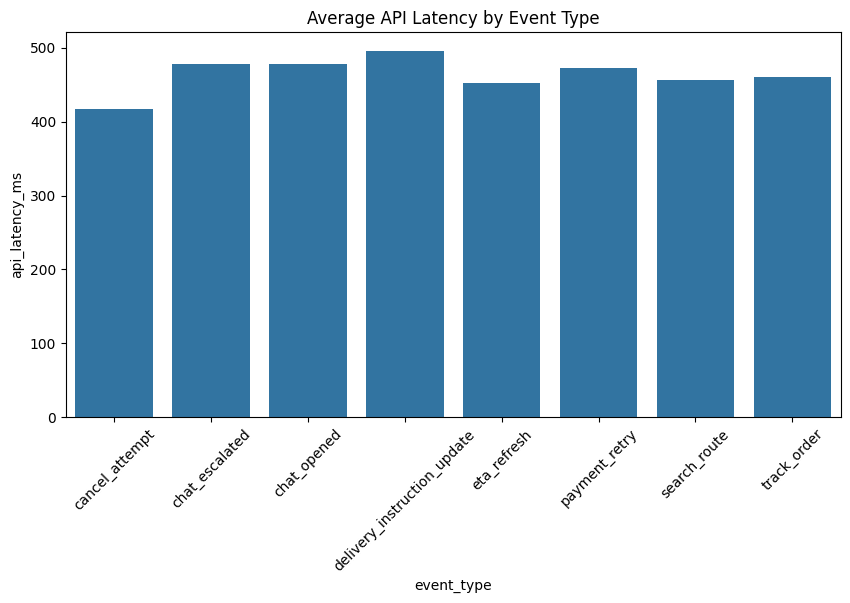

In [9]:
# ============================================================
# STEP 11 — APP PERFORMANCE ANALYSIS
# ============================================================

app_analysis = app_events.groupby(
    'event_type'
).agg({
    'api_latency_ms':'mean',
    'success_flag':'mean'
}).reset_index()

print(app_analysis)

# Visualisation

plt.figure(figsize=(10,5))

sns.barplot(
    data=app_analysis,
    x='event_type',
    y='api_latency_ms'
)

plt.xticks(rotation=45)

plt.title('Average API Latency by Event Type')

plt.show()

INTERPRETATION:

Platform event analysis evaluates digital service performance
across customer interactions.

High API latency may negatively affect customer experience
and mobile platform reliability.

In [10]:
# ============================================================
# STEP 12 — OPERATIONAL ANOMALY DETECTION
# ============================================================

master_df['risk_score'] = (
    master_df['manual_route_override_count'] * 2
    +
    master_df['proof_of_completion_missing'] * 3
)

high_risk_deliveries = master_df[
    master_df['risk_score'] >= 5
]

print(high_risk_deliveries[
    [
        'delivery_id',
        'driver_id',
        'hub_name',
        'delivery_status',
        'risk_score'
    ]
].head(20))

    delivery_id driver_id        hub_name delivery_status  risk_score
11      DL00012      D051    Central Core          Failed           6
14      DL00015      D067       West Gate          OnTime           6
18      DL00019      D026     Airport Hub          OnTime           8
20      DL00021      D117   Midtown Relay          OnTime           8
40      DL00041      D100   Midtown Relay          Failed           9
51      DL00052      D168   Midtown Relay         Delayed           5
54      DL00055      D069       West Gate         Delayed          13
58      DL00059      D027    Central Core         Delayed           6
59      DL00060      D005      South Link         Delayed           5
72      DL00073      D141   Midtown Relay          OnTime           6
74      DL00075      D169      South Link          OnTime           6
75      DL00076      D120  North Exchange          OnTime           6
76      DL00077      D094       West Gate         Delayed           6
80      DL00081     

INTERPRETATION:

Operational anomaly detection identifies deliveries
with unusually high operational risk characteristics.

This supports proactive intervention and operational monitoring.

  customer_type  loyalty_score  customer_rating_post_delivery
0      Consumer      60.698696                       3.869275
1    Enterprise      58.471484                       3.861609
2           SME      56.768399                       3.846415


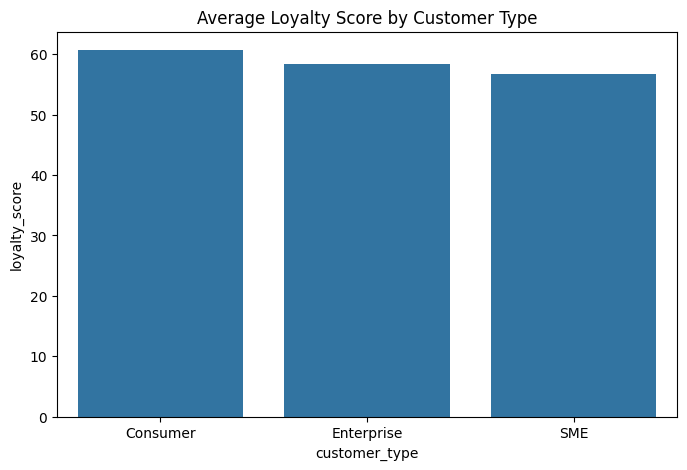

In [11]:
# ============================================================
# STEP 13 — CUSTOMER LOYALTY ANALYSIS
# ============================================================

loyalty_analysis = master_df.groupby(
    'customer_type'
).agg({
    'loyalty_score':'mean',
    'customer_rating_post_delivery':'mean'
}).reset_index()

print(loyalty_analysis)

# Visualisation

plt.figure(figsize=(8,5))

sns.barplot(
    data=loyalty_analysis,
    x='customer_type',
    y='loyalty_score'
)

plt.title('Average Loyalty Score by Customer Type')

plt.show()

INTERPRETATION:

Customer loyalty analysis evaluates engagement
and satisfaction across customer segments.

Lower loyalty scores may indicate dissatisfaction
or inconsistent operational service quality.

      incident_type  count
0      AppSyncError     31
1      BatteryAlert     36
2    CustomerNoShow     44
3      ProofMissing     46
4    RouteDeviation     43
5    SafetyNearMiss     14
6  TemperatureIssue     29
7      VehicleFault     37


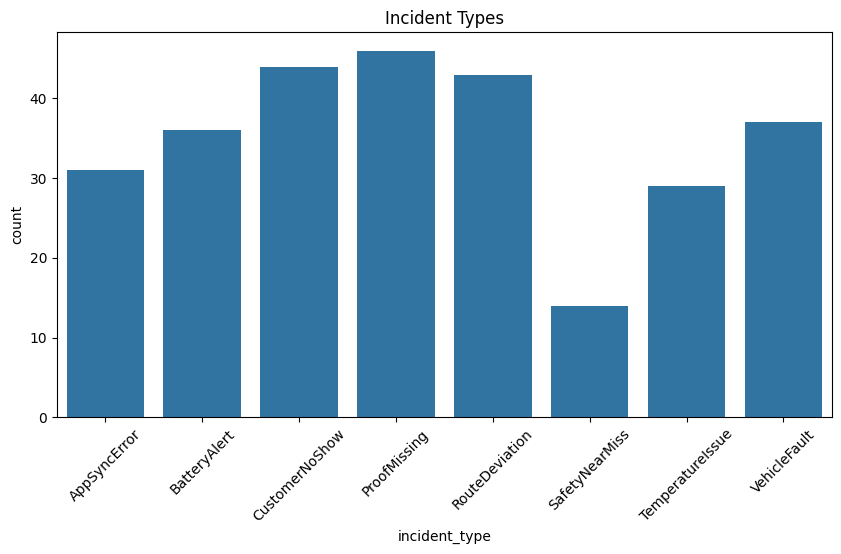

In [12]:
# ============================================================
# STEP 14 — INCIDENT ANALYSIS
# ============================================================

incident_analysis = incidents.groupby(
    'incident_type'
).size().reset_index(name='count')

print(incident_analysis)

# Visualisation

plt.figure(figsize=(10,5))

sns.barplot(
    data=incident_analysis,
    x='incident_type',
    y='count'
)

plt.xticks(rotation=45)

plt.title('Incident Types')

plt.show()

INTERPRETATION:

Incident analysis identifies the most frequent operational
and technical disruptions affecting service delivery.

The findings support predictive maintenance
and operational optimisation strategies.

In [13]:
# ============================================================
# FINAL SUMMARY
# ============================================================

print("""
=========================================================
PYTHON PROCESSING COMPLETE
=========================================================

Completed Analyses:
1. Data cleaning and preprocessing
2. Master dataset integration
3. Delivery failure analysis
4. Hub performance analysis
5. Driver risk analysis
6. Vehicle health analysis
7. Complaint analysis
8. App performance analysis
9. Operational anomaly detection
10. Customer loyalty analysis
11. Incident analysis

NEXT NOTEBOOK:
5_mongodb_design.ipynb
=========================================================
""")


PYTHON PROCESSING COMPLETE

Completed Analyses:
1. Data cleaning and preprocessing
2. Master dataset integration
3. Delivery failure analysis
4. Hub performance analysis
5. Driver risk analysis
6. Vehicle health analysis
7. Complaint analysis
8. App performance analysis
9. Operational anomaly detection
10. Customer loyalty analysis
11. Incident analysis

NEXT NOTEBOOK:
5_mongodb_design.ipynb

